# cleaning title_basics.tsv

In [2]:
import pandas as pd
#loading the tsv file 
df=pd.read_csv('title.basics.tsv', sep='\t', dtype=str, na_values='\\N')
#filtering for rows where titleType is exactly movie
movie_df=df[df['titleType']=='movie']w
#save to a new csv file 
movie_df.to_csv('title_basics_movies.csv', index=False)

In [10]:
#load the edited csv
title_basics=pd.read_csv('title_basics_movies.csv')
#removing irrelevant columns 
title_basics=title_basics.drop(columns=['tconst', 'titleType', 'primaryTitle', 'isAdult', 'endYear', 'runtimeMinutes', 'startYear'])
#renaming the column 'originalTitle' to 'title'so it matches with success_metrics.csv csv
title_basics=title_basics.rename(columns={'originalTitle': 'title'})
#saving the cleaned csv
title_basics.to_csv('genres.csv', index=False)
title_basics.head()


,title,genres
0,Miss Jerry,Romance
1,The Corbett-Fitzsimmons Fight,"Documentary,News,Sport"
2,Bohemios,NaN
3,The Story of the Kelly Gang,"Action,Adventure,Biography"
4,L'enfant prodigue,Drama


# joining genres.csv and succes_metrics.csv

In [58]:
genres=pd.read_csv('genres.csv')
success_metrics=pd.read_csv('success_metrics.csv')
#putting both title columns in lower case so they will match 
genres['title']=genres['title'].str.strip().str.lower()
success_metrics['title']=success_metrics['title'].str.strip().str.lower()
#inner join on title column
df=pd.merge(genres, success_metrics, on='title', how='inner')
#there were lots of duplicated so i deleted movies that were duplicated in both title and awards as there are some films with the same title 
df=merged_df.drop_duplicates(subset=['title', 'awards_all'])
df.to_csv('genres_success.csv', index=False)
df.head()



,title,genres,critic_score,audience_score,awards_all,nomination_count,award_count,awards_won,awards_nominated,worldwide_gross
0,hamlet,Drama,100%,91%,Oscars - ACTOR (Won)\nOscars - ACTRESS IN A SU...,15,5,Oscars - ACTOR (Won)\nOscars - ART DIRECTION (...,Oscars - ACTRESS IN A SUPPORTING ROLE (Nominat...,"$22,493,727"
6,carmen,NaN,78%,NaN,Oscars - FOREIGN LANGUAGE FILM (Nominated)\nBA...,6,1,BAFTAs - Film | Foreign Language Film in 1985 ...,Oscars - FOREIGN LANGUAGE FILM (Nominated)\nBA...,NaN
8,oliver twist,Drama,NaN,NaN,BAFTAs - Film | British Film in 1949 (Nominated),1,0,NaN,BAFTAs - Film | British Film in 1949 (Nominated),"$26,670,920"
17,macbeth,"Crime,Drama",NaN,NaN,BAFTAs - Film | Anthony Asquith Memorial Award...,1,0,NaN,BAFTAs - Film | Anthony Asquith Memorial Award...,NaN
19,the prisoner of zenda,Adventure,NaN,NaN,Oscars - ART DIRECTION (Nominated)\nOscars - M...,2,0,NaN,Oscars - ART DIRECTION (Nominated)\nOscars - M...,NaN


# checking what genres there are in the dataset

In [55]:
df= pd.read_csv('genres_success.csv')
all_genres=df['genres'].dropna().str.split(',').explode().str.strip().unique()
print(sorted(all_genres))

['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']


# creating plot 

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
/var/folders/h9/n0byq01s2rn56952m3qk8p800000gn/T/ipykernel_46752/2590109203.py:13: SyntaxWarning: invalid escape sequence '\$'
  df_exploded['worldwide_gross']=df_exploded['worldwide_gross'].replace({'\$': '', ',': ''}, regex=True)


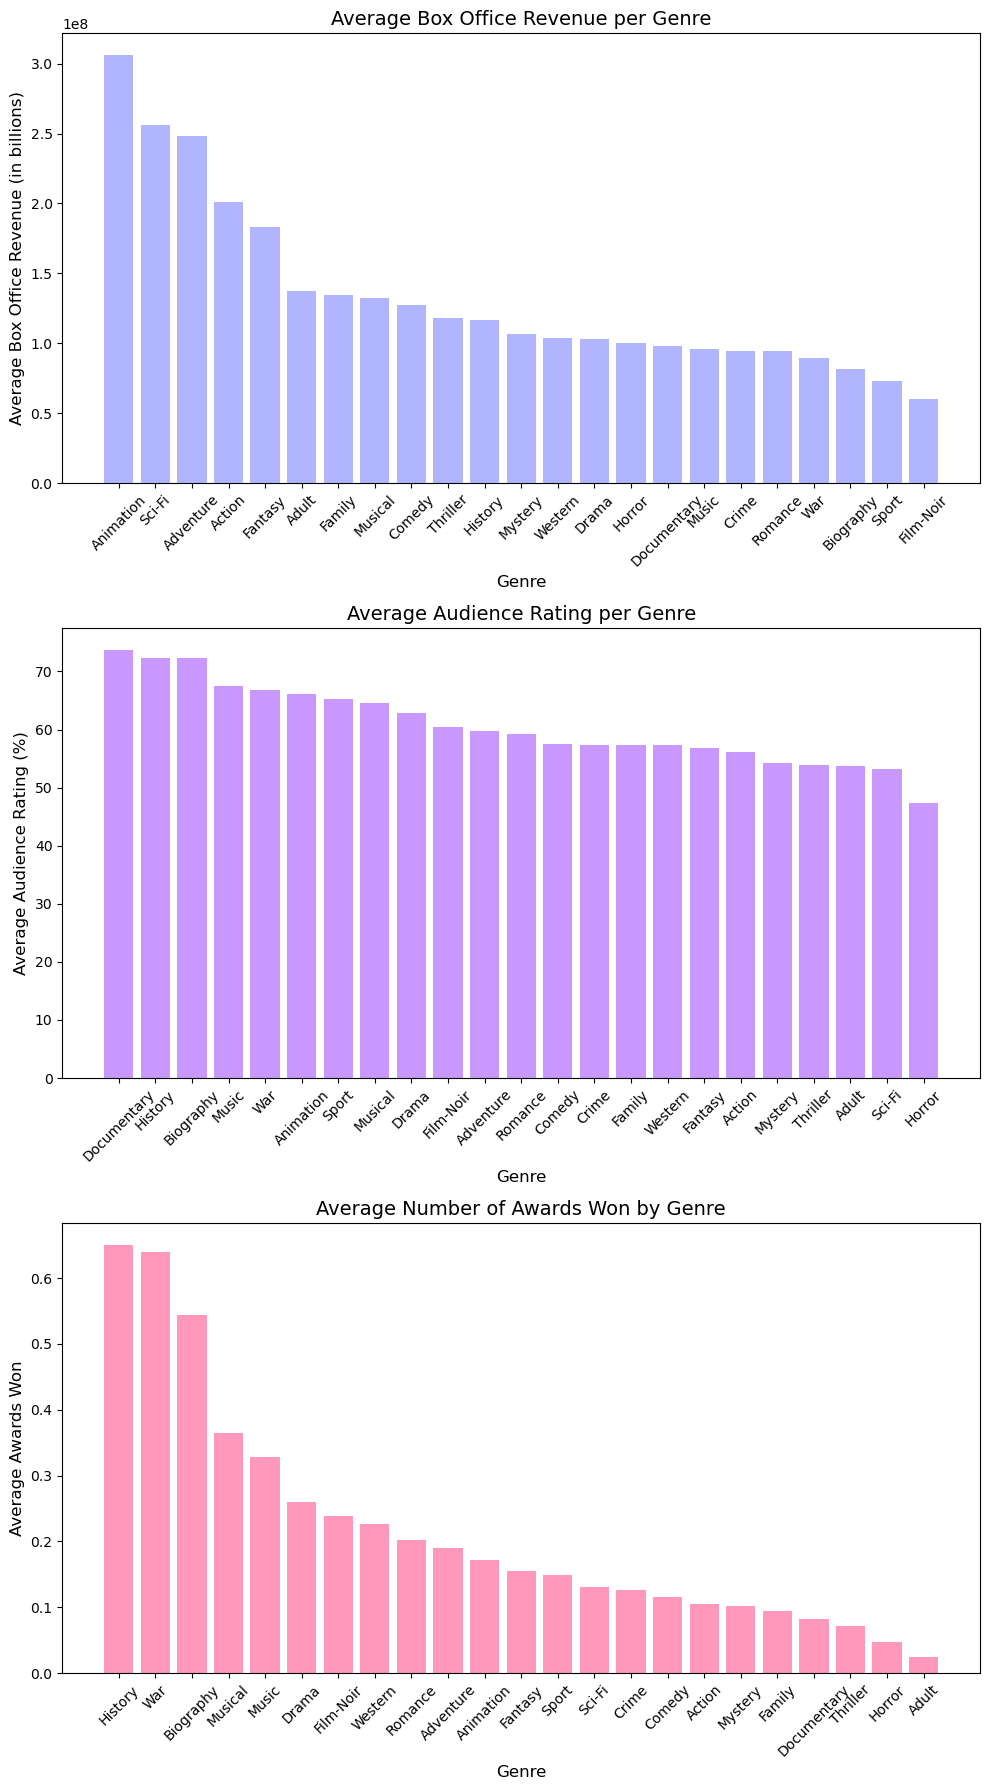

In [60]:
import matplotlib.pyplot as plt
df=pd.read_csv('genres_success.csv')
df['genres']=df['genres'].str.split(',')
#flattening the list and explode to get each genre as a separate row
df_exploded=df.explode('genres')
df_exploded['genres']=df_exploded['genres'].str.strip()

#filtering for whcih genres are in the dataset
valid_genres=['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']
df_exploded=df_exploded[df_exploded['genres'].isin(valid_genres)]

#removing dollars and percentage signs so that scores and gross are numeric
df_exploded['worldwide_gross']=df_exploded['worldwide_gross'].replace({'\$': '', ',': ''}, regex=True)
df_exploded['worldwide_gross']=pd.to_numeric(df_exploded['worldwide_gross'], errors='coerce')
df_exploded['audience_score']=df_exploded['audience_score'].replace({'%': ''}, regex=True)
df_exploded['audience_score']=pd.to_numeric(df_exploded['audience_score'], errors='coerce')

#grouping by genre and calculating mean values
genre_box_office=df_exploded.groupby('genres')['worldwide_gross'].mean().sort_values(ascending=False)
genre_audience_rating=df_exploded.groupby('genres')['audience_score'].mean().sort_values(ascending=False)
genre_awards_avg=df_exploded.groupby('genres')['award_count'].mean().sort_values(ascending=False)

#creating plot
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

#average box office revenue by genre
axes[0].bar(genre_box_office.index, genre_box_office.values, color='#656CFE', alpha=0.5)
axes[0].set_title('Average Box Office Revenue per Genre', fontsize=14)
axes[0].set_xlabel('Genre', fontsize=12)
axes[0].set_ylabel('Average Box Office Revenue (in billions)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

#average audience rating
axes[1].bar(genre_audience_rating.index, genre_audience_rating.values, color='#9333FF', alpha=0.5)
axes[1].set_title('Average Audience Rating per Genre', fontsize=14)
axes[1].set_xlabel('Genre', fontsize=12)
axes[1].set_ylabel('Average Audience Rating (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

#awards won by genre 
axes[2].bar(genre_awards_avg.index, genre_awards_avg.values, color='#FF3377', alpha=0.5)
axes[2].set_title('Average Number of Awards Won by Genre', fontsize=14)
axes[2].set_xlabel('Genre', fontsize=12)
axes[2].set_ylabel('Average Awards Won', fontsize=12)
axes[2].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()
